In [8]:
# baixa o repositório na máquina do colab, pra permitir o import de
# módulos do repositório
!rm -fr /content/deep-learning-pa1
!git clone https://github.com/nicolasspaniol/deep-learning-pa1.git

# adiciona o caminho do repositório clonado no path
import sys
sys.path.insert(0,'/content/deep-learning-pa1/src')

Cloning into 'deep-learning-pa1'...
remote: Enumerating objects: 188, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 188 (delta 15), reused 9 (delta 9), pack-reused 159 (from 1)
Receiving objects: 100% (188/188), 5.10 MiB | 22.30 MiB/s, done.
Resolving deltas: 100% (77/77), done.


In [11]:
# local files
import utils
from synthetic_dataset import SyntheticEllipseDataset
from resunet import ResUNet
from bbbc038_dataset import BBBC038Dataset

import os
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [23]:
# Carregando os dados: BBBC038
# Verifica se a pasta já não existe antes de baixar

if not os.path.exists('./data/stage1_train'):
    !wget https://data.broadinstitute.org/bbbc/BBBC038/stage1_train.zip -P ./data
    !cd data && unzip -q stage1_train.zip -d stage1_train
    !rm ./data/stage1_train.zip

if not os.path.exists('./data/stage1_test'):
    !wget https://data.broadinstitute.org/bbbc/BBBC038/stage1_test.zip -P ./data
    !cd data && unzip -q stage1_test.zip -d stage1_test
    !rm ./data/stage1_test.zip

--2026-09-11 17:16:52--  https://data.broadinstitute.org/bbbc/BBBC038/stage1_train.zip
Resolving data.broadinstitute.org (data.broadinstitute.org)... 69.173.68.137
Connecting to data.broadinstitute.org (data.broadinstitute.org)|69.173.68.137|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 82923446 (79M) [application/zip]
Saving to: ‘./data/stage1_train.zip’

stage1_train.zip    100%[===================>]  79.08M  15.2MB/s    in 6.8s    

2026-09-11 17:17:00 (11.7 MB/s) - ‘./data/stage1_train.zip’ saved [82923446/82923446]

--2026-09-11 17:17:02--  https://data.broadinstitute.org/bbbc/BBBC038/stage1_test.zip
Resolving data.broadinstitute.org (data.broadinstitute.org)... 69.173.68.137
Connecting to data.broadinstitute.org (data.broadinstitute.org)|69.173.68.137|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9545388 (9.1M) [application/zip]
Saving to: ‘./data/stage1_test.zip’

stage1_test.zip     100%[===================>]   9.10M  4.88

In [24]:
# carrega o dataset

dataset = BBBC038Dataset(True, './data/stage1_train')
train_dataset, val_dataset = random_split(dataset, [0.8, 0.2])
test_dataset = BBBC038Dataset(False, './data/stage1_test')

In [38]:
# cria o modelo e carrega os pesos

model = ResUNet(3, 1)
model.load_state_dict(torch.load('binary_weights', weights_only=True))
model.eval()
model = model.to(device)

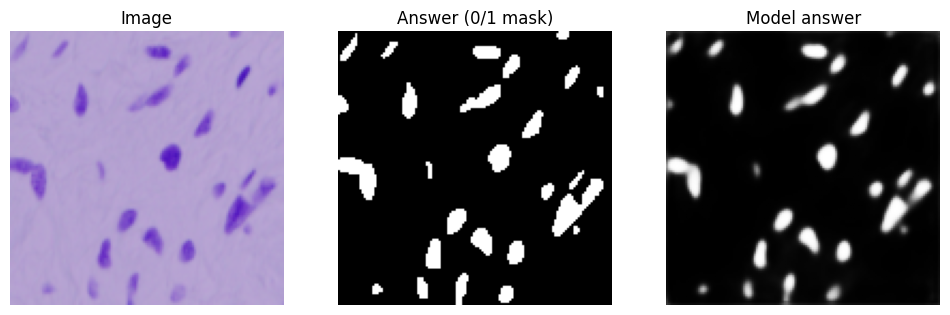

In [42]:
# Verificando a saída do modelo

for _, img, mask, _ in DataLoader(train_dataset, shuffle=True):
    img, mask = img.to(device), mask.to(device)

    y = F.sigmoid(model(img))[0,0].cpu().detach().numpy()
    img = img[0].permute(1, 2, 0).cpu().detach().numpy()
    mask = mask[0].cpu().detach().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img)
    axes[0].set_title("Image")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Answer (0/1 mask)")
    axes[1].axis("off")

    axes[2].imshow(y, cmap="gray")
    axes[2].set_title("Model answer")
    axes[2].axis("off")

    plt.show()

    break